In [147]:
import pandas as pd
from classify_response import classify_response, classify_response_factual_recall
import os #SPECIFIC TO ATHU OSCAR
import sys
os.environ["HF_HOME"] = "/oscar/scratch/aparasel/hf_cache"
#os.environ["TRANSFORMERS_CACHE"] = "/oscar/scratch/aparasel/hf_cache/transformers"
#os.environ["DATASETS_CACHE"] = "/oscar/scratch/aparasel/hf_cache/datasets"
os.environ["HF_HUB_CACHE"] = "/oscar/scratch/aparasel/hf_cache/hub"

import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import re
import json
from tqdm import tqdm
tqdm.pandas()

In [148]:
# JUDGE_MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"

# tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL_NAME, use_fast=True)
# model = AutoModelForCausalLM.from_pretrained(
#     JUDGE_MODEL_NAME,
#     device_map="auto",
#     torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
# )
# model.eval()

# class Llama3Judge:
#     def __init__(self, model, tokenizer):
#         self.model = model
#         self.tokenizer = tokenizer

#     @torch.inference_mode()
#     def generate(self, prompt: str, temperature: float = 0.0, max_tokens: int = 5) -> str:
#         # Llama 3 Instruct uses chat template
#         messages = [{"role": "user", "content": prompt}]
#         if hasattr(self.tokenizer, "apply_chat_template"):
#             text = self.tokenizer.apply_chat_template(
#                 messages, tokenize=False, add_generation_prompt=True
#             )
#         else:
#             text = prompt

#         inputs = self.tokenizer(text, return_tensors="pt", padding=False).to(self.model.device)

#         do_sample = (temperature is not None) and (temperature > 0.0)
#         out = self.model.generate(
#             **inputs,
#             max_new_tokens=max_tokens,
#             do_sample=do_sample,
#             temperature=temperature if do_sample else None,
#             top_p=0.95 if do_sample else None,
#             pad_token_id=self.tokenizer.eos_token_id,
#             eos_token_id=self.tokenizer.eos_token_id,
#         )

#         prompt_len = inputs["input_ids"].shape[1]
#         gen_tokens = out[0, prompt_len:]
#         return self.tokenizer.decode(gen_tokens, skip_special_tokens=True)

# judge_model = Llama3Judge(model, tokenizer)
judge_model = None

In [149]:
MAPPING = {"Temporal_error": "What year was the entity born?", "location_error":"What is the nationality of the entity?", "Career_error":"What is the occupation of the entity?"}
def load_factual_recall_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_qwen_celeb_vision_split",classify=False,num_layers=20):
    dfs_vis = []
    for i in range(num_layers):
        df_temp = pd.read_csv(f"{base}{i}.csv")
        if classify:
            df_temp["Pred"] = df_temp.progress_apply(
                        lambda x: classify_response_factual_recall(
                            query=MAPPING[x["Category"]],
                            parametric_ans=x["Parametric_ans"],
                            response=x['New_Answer'],
                            judge_model=judge_model,
                        ),
                        axis=1,
                    )
            df_temp.to_csv(f"{base}{i}.csv")
        df_temp = df_temp.drop_duplicates(['Entity', 'Category'])
        dfs_vis.append(df_temp)
    df_all = pd.concat(dfs_vis, ignore_index=True)
    return df_all

In [150]:
def load_forwardpatch_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_qwen_celeb_vision_split",classify=True,num_layers=20):
    dfs_vis = []
    for i in range(num_layers):
        df_temp = pd.read_csv(f"{base}{i}.csv")
        if classify:
            df_temp["Pred"] = df_temp.progress_apply(
                        lambda x: classify_response(
                            query=x["Query"],
                            parametric_ans=x["Parametric_ans"],
                            contextual_ans=x['Contextual_ans'],
                            response=x['New_Answer'],
                            judge_model=judge_model,
                        ),
                        axis=1,
                    )
            df_temp.to_csv(f"{base}{i}.csv")
        #df_temp = df_temp.drop_duplicates(['Entity', 'Category'])
        dfs_vis.append(df_temp)
    df_all = pd.concat(dfs_vis, ignore_index=True)
    df_all['orig_pred_group'] = df_all['Group'].apply(lambda x: "CONTEXTUAL_ANS" if ((x == "VisTxtCont") or (x == "VisCont_TxtParam")) else "PARAMETRIC_ANSWER")
    return df_all

In [151]:
df_qwen_vis_fact_rec = load_factual_recall_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_qwen_celeb_vision_layer2_split",classify=False,num_layers=8)
df_qwen_vis_fact_rec.head(3)

,Unnamed: 0,ID,Entity,Category,Query,Group,Original_output,Original_top_token,Mis_Knowledge_Key,Parametric_ans,Contextual_ans,src_start,dst_start,num_layers,New_Answer,TopDecodedTokenID,TopDecodedToken,Pred
0,0,1,Taylor Swift,Temporal_error,What year was the entity born?,VisTxtCont,1988.,1,mis_knowledge1,1989,1988,2,2,1,1989,16,1,CORRECT
1,2,1,Taylor Swift,location_error,What is the nationality of the entity?,VisTxtCont,Canadian.,Canadian,mis_knowledge1,American,Canadian,2,2,1,American.,28418,American,CORRECT
2,4,1,Taylor Swift,Career_error,What is the occupation of the entity?,VisTxtCont,Novelist.,Nov,mis_knowledge1,singer-songwriter,novelist,2,2,1,Singer-songwriter.,50,S,CORRECT


In [152]:
# LOAD forwarpatch df and ADD WHETHER IT KNOWS THE FACT
df_qwen_vis = load_forwardpatch_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_qwen_celeb_vision_ctxt_mem_conf_split",classify=False, num_layers=8)
#print(df_qwen_vis)
df_qwen_vis = df_qwen_vis[df_qwen_vis['Category'] == 'Career_error']
df_qwen_vis_fact_rec  = df_qwen_vis_fact_rec.copy()
df_qwen_vis = df_qwen_vis.copy()

# build mapping table: one row per (Entity, Category, num_layers)
keys = ["Entity", "Category", "num_layers"]
fr_map = (
    df_qwen_vis_fact_rec[keys + ["Pred"]]
    .drop_duplicates(subset=keys, keep="last")
    .rename(columns={"Pred": "Knows_Fact"})
)

# left-join onto ctxt-mem df
df_qwen_vis = df_qwen_vis.merge(fr_map, on=keys, how="left")
df_qwen_vis['Knows_Fact'] = df_qwen_vis['Knows_Fact'] == 'CORRECT'
df_qwen_vis_fact_rec['Pred'] = df_qwen_vis_fact_rec['Pred'] == 'CORRECT'
df_qwen_vis.head(3)

,Unnamed: 0,ID,Entity,Category,Query,Group,Original_output,Original_top_token,Mis_Knowledge_Key,Parametric_ans,...,src_start,dst_start,num_layers,New_Answer,TopDecodedTokenID,TopDecodedToken,Pred,Unnamed: 0.1,orig_pred_group,Knows_Fact
0,4,1,Taylor Swift,Career_error,What is the occupation of the entity?,VisTxtCont,Novelist.,Nov,mis_knowledge1,singer-songwriter,...,2,2,1,Novelist.,18944,Nov,CONTEXTUAL_ANS,NaN,CONTEXTUAL_ANS,True
1,5,1,Taylor Swift,Career_error,What is the occupation of the entity?,VisTxtCont,Chef.,Chef,mis_knowledge2,singer-songwriter,...,2,2,1,Chef.,93903,Chef,CONTEXTUAL_ANS,NaN,CONTEXTUAL_ANS,True
2,8,2,Elon Musk,Career_error,What is the occupation of the entity?,VisTxtCont,Professional athlete.,Professional,mis_knowledge1,"business magnate, investor, and engineer",...,2,2,1,Professional athlete.,57513,Professional,CONTEXTUAL_ANS,NaN,CONTEXTUAL_ANS,True


In [153]:

#For contextual answers vs parametric does it know the fact 
print(df_qwen_vis.groupby(['orig_pred_group', 'num_layers'])['Knows_Fact'].mean())


orig_pred_group    num_layers
CONTEXTUAL_ANS     1             0.960000
                   2             0.960000
                   3             0.960000
                   4             0.906667
                   5             0.840000
                   6             0.826667
                   7             0.840000
                   8             0.600000
PARAMETRIC_ANSWER  1             0.944724
                   2             0.924623
                   3             0.944724
                   4             0.934673
                   5             0.929648
                   6             0.904523
                   7             0.869347
                   8             0.809045
Name: Knows_Fact, dtype: float64


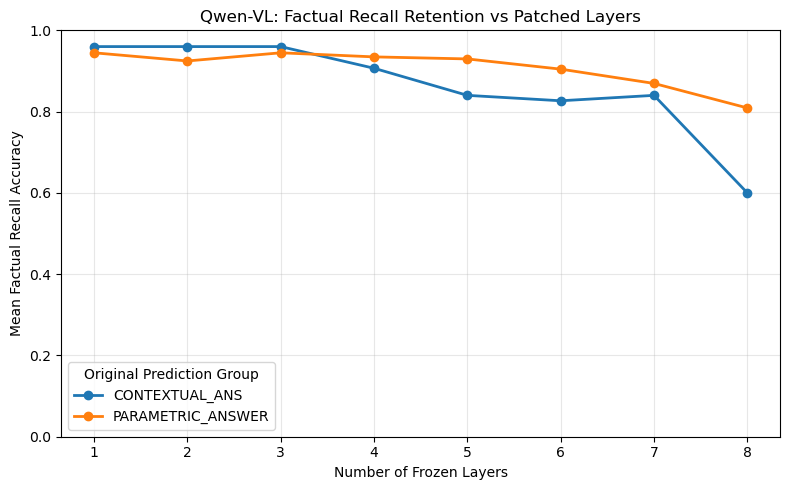

In [154]:

df_plot = (
    df_qwen_vis
    .groupby(['orig_pred_group', 'num_layers'])['Knows_Fact']
    .mean()
    .reset_index()
)

df_pivot = df_plot.pivot(
    index='num_layers',
    columns='orig_pred_group',
    values='Knows_Fact'
)

plt.figure(figsize=(8, 5))

for col in df_pivot.columns:
    plt.plot(
        df_pivot.index,
        df_pivot[col],
        marker='o',
        linewidth=2,
        label=col
    )

plt.xlabel("Number of Frozen Layers")
plt.ylabel("Mean Factual Recall Accuracy")
plt.title("Qwen-VL: Factual Recall Retention vs Patched Layers")
plt.ylim(0.0, 1.0)
plt.xticks(df_pivot.index)
plt.grid(alpha=0.3)
plt.legend(title="Original Prediction Group")
plt.tight_layout()
plt.show()

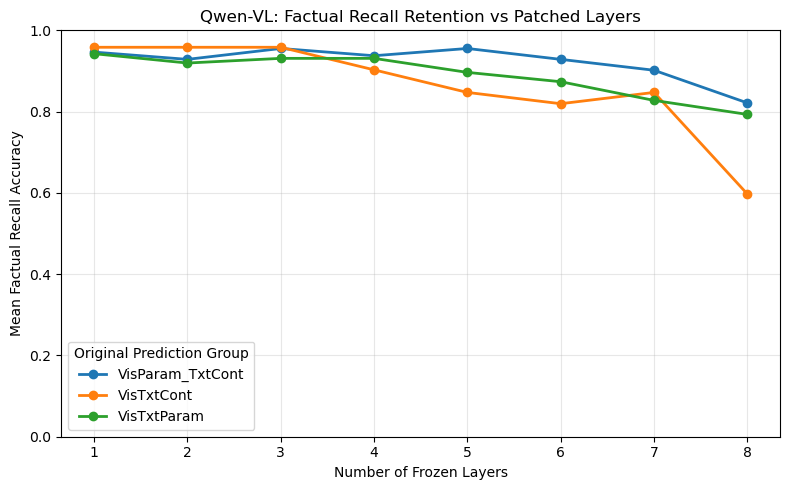

In [155]:

df_plot = (
    df_qwen_vis[df_qwen_vis['Group'] != "VisCont_TxtParam"]
    .groupby(['Group', 'num_layers'])['Knows_Fact']
    .mean()
    .reset_index()
)

df_pivot = df_plot.pivot(
    index='num_layers',
    columns='Group',
    values='Knows_Fact'
)

plt.figure(figsize=(8, 5))

for col in df_pivot.columns:
    plt.plot(
        df_pivot.index,
        df_pivot[col],
        marker='o',
        linewidth=2,
        label=col
    )

plt.xlabel("Number of Frozen Layers")
plt.ylabel("Mean Factual Recall Accuracy")
plt.title("Qwen-VL: Factual Recall Retention vs Patched Layers")
plt.ylim(0.0, 1.0)
plt.xticks(df_pivot.index)
plt.grid(alpha=0.3)
plt.legend(title="Original Prediction Group")
plt.tight_layout()
plt.show()

In [156]:
df_qwen_vis = df_qwen_vis[df_qwen_vis['Knows_Fact']]

In [157]:
#How does each group switch over the layers
df_qwen_vis['Switched'] = ((df_qwen_vis['Pred'] != df_qwen_vis['orig_pred_group']) & (df_qwen_vis['Pred'] != 'neither'))
df_qwen_vis.groupby(['orig_pred_group', 'num_layers'])['Switched'].mean()

orig_pred_group    num_layers
CONTEXTUAL_ANS     1             0.013889
                   2             0.055556
                   3             0.138889
                   4             0.147059
                   5             0.095238
                   6             0.080645
                   7             0.095238
                   8             0.066667
PARAMETRIC_ANSWER  1             0.005319
                   2             0.114130
                   3             0.058511
                   4             0.080645
                   5             0.183784
                   6             0.194444
                   7             0.242775
                   8             0.416149
Name: Switched, dtype: float64

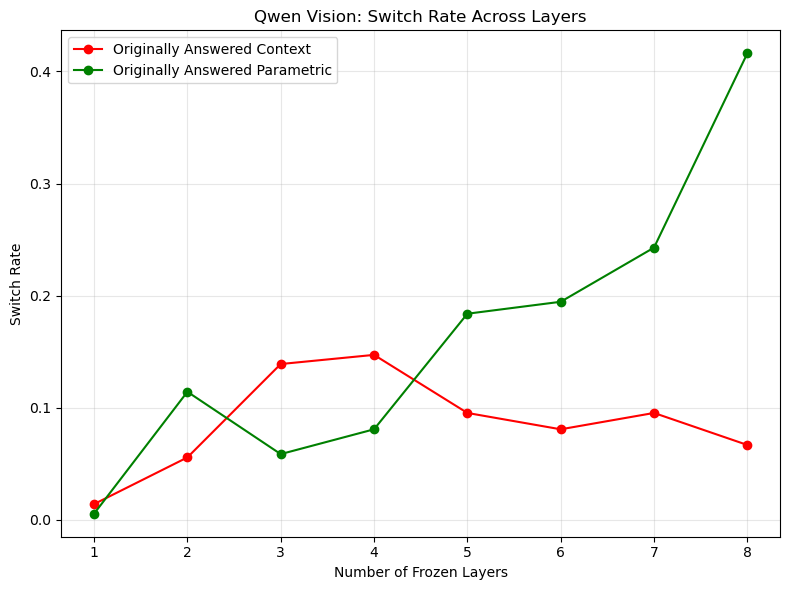

In [158]:


# Compute grouped means
grouped = (
    df_qwen_vis
    .groupby(['orig_pred_group', 'num_layers'])['Switched']
    .mean()
    .reset_index()
)

# Split groups
df_context = grouped[grouped['orig_pred_group'] == "CONTEXTUAL_ANS"]
df_param   = grouped[grouped['orig_pred_group'] == "PARAMETRIC_ANSWER"]

plt.figure(figsize=(8, 6))

# Plot lines
plt.plot(
    df_context['num_layers'],
    df_context['Switched'],
    marker='o',
    color='red',
    label="Originally Answered Context"
)

plt.plot(
    df_param['num_layers'],
    df_param['Switched'],
    marker='o',
    color='green',
    label="Originally Answered Parametric"
)

plt.xlabel("Number of Frozen Layers")
plt.ylabel("Switch Rate")
plt.title("Qwen Vision: Switch Rate Across Layers")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [159]:
df_qwen_vis.groupby(['Group', 'num_layers'])['Switched'].mean()

Group             num_layers
VisCont_TxtParam  1             0.000000
                  2             0.333333
                  3             0.333333
                  4             0.666667
                  5             0.500000
                  6             0.333333
                  7             0.500000
                  8             0.000000
VisParam_TxtCont  1             0.009434
                  2             0.192308
                  3             0.102804
                  4             0.133333
                  5             0.299065
                  6             0.298077
                  7             0.366337
                  8             0.586957
VisTxtCont        1             0.014493
                  2             0.043478
                  3             0.130435
                  4             0.123077
                  5             0.081967
                  6             0.067797
                  7             0.081967
                  8         

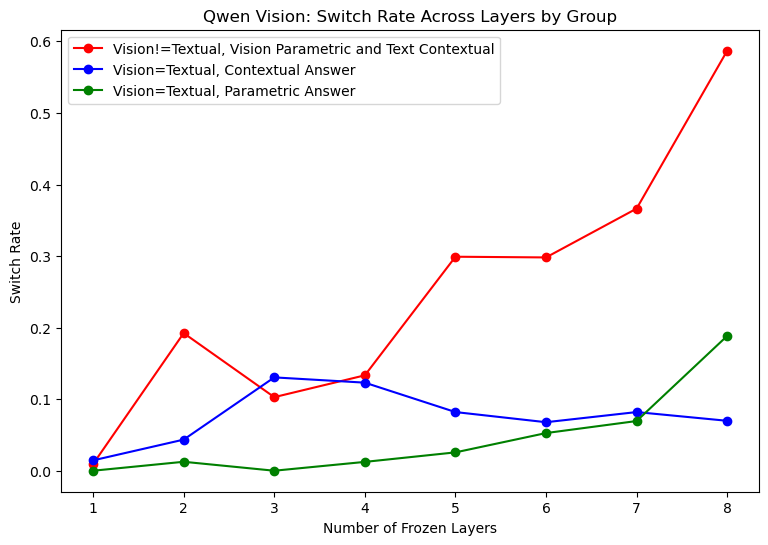

In [160]:
import matplotlib.pyplot as plt

# Compute grouped means
grouped = (
    df_qwen_vis
    .groupby(['Group', 'num_layers'])['Switched']
    .mean()
    .reset_index()
)

# Select only the 3 groups you care about
groups_to_plot = ["VisParam_TxtCont", "VisTxtCont", "VisTxtParam"]
grouped = grouped[grouped["Group"].isin(groups_to_plot)]

# Color map (clean + distinct)
color_map = {
    "VisParam_TxtCont": "red",
    "VisTxtCont": "blue",
    "VisTxtParam": "green"
}
label_map = {
    "VisParam_TxtCont": "Vision!=Textual, Vision Parametric and Text Contextual",
    "VisTxtCont": "Vision=Textual, Contextual Answer",
    "VisTxtParam": "Vision=Textual, Parametric Answer"
}

plt.figure(figsize=(9, 6))

for g in groups_to_plot:
    df_g = grouped[grouped["Group"] == g]
    plt.plot(
        df_g["num_layers"],
        df_g["Switched"],
        marker='o',
        label=label_map[g],   # ← change here
        color=color_map[g]
    )
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Switch Rate")
plt.title("Qwen Vision: Switch Rate Across Layers by Group")
plt.legend()
plt.show()

In [161]:
#how many switch to neither 
df_qwen_vis['Switched2Neither'] = ((df_qwen_vis['Pred'] != df_qwen_vis['orig_pred_group']) & (df_qwen_vis['Pred'] == 'neither'))
df_qwen_vis.groupby(['orig_pred_group', 'num_layers'])['Switched2Neither'].mean()

orig_pred_group    num_layers
CONTEXTUAL_ANS     1             0.083333
                   2             0.083333
                   3             0.083333
                   4             0.088235
                   5             0.095238
                   6             0.096774
                   7             0.079365
                   8             0.022222
PARAMETRIC_ANSWER  1             0.000000
                   2             0.005435
                   3             0.000000
                   4             0.005376
                   5             0.010811
                   6             0.011111
                   7             0.005780
                   8             0.006211
Name: Switched2Neither, dtype: float64

# Back patch

In [162]:
# LOAD forwarpatch df and ADD WHETHER IT KNOWS THE FACT
df_qwen_vis = load_forwardpatch_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_qwen_celeb_vision_ctxt_mem_conf_split_backpatch",classify=False, num_layers=1)
#print(df_qwen_vis)
df_qwen_vis = df_qwen_vis[df_qwen_vis['Category'] == 'Career_error']

df_qwen_vis.head(3)

,Unnamed: 0,ID,Entity,Category,Query,Group,Original_output,Original_top_token,Mis_Knowledge_Key,Parametric_ans,Contextual_ans,src_start,dst_start,num_layers,New_Answer,TopDecodedTokenID,TopDecodedToken,Pred,orig_pred_group
4,4,1,Taylor Swift,Career_error,What is the occupation of the entity?,VisTxtCont,Novelist.,Nov,mis_knowledge1,singer-songwriter,novelist,4,0,1,Singer-songwriter,50,S,PARAMETRIC_ANSWER,CONTEXTUAL_ANS
5,5,1,Taylor Swift,Career_error,What is the occupation of the entity?,VisTxtCont,Chef.,Chef,mis_knowledge2,singer-songwriter,chef,4,0,1,Singer-songwriter,50,S,PARAMETRIC_ANSWER,CONTEXTUAL_ANS
8,8,2,Elon Musk,Career_error,What is the occupation of the entity?,VisTxtCont,Professional athlete.,Professional,mis_knowledge1,"business magnate, investor, and engineer",professional athlete,4,0,1,Professional athlete.,57513,Professional,CONTEXTUAL_ANS,CONTEXTUAL_ANS


In [163]:
#How does each group switch over the layers
df_qwen_vis['Switched'] = ((df_qwen_vis['Pred'] != df_qwen_vis['orig_pred_group']) & (df_qwen_vis['Pred'] != 'neither'))
df_qwen_vis.groupby(['orig_pred_group', 'num_layers'])['Switched'].mean()

orig_pred_group    num_layers
CONTEXTUAL_ANS     1             0.240000
PARAMETRIC_ANSWER  1             0.025126
Name: Switched, dtype: float64

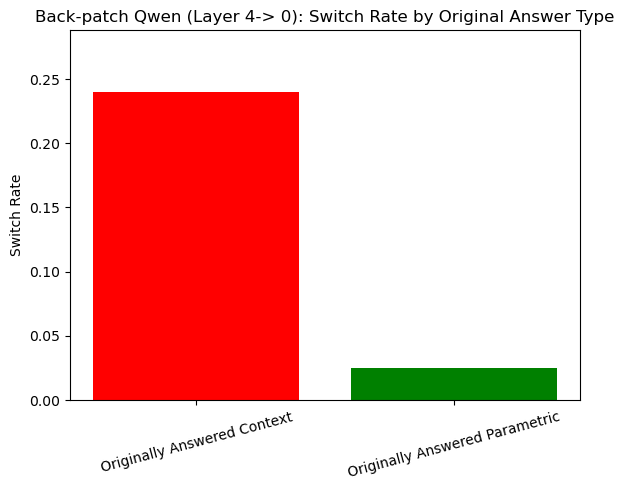

In [164]:
import matplotlib.pyplot as plt

# Compute means (only one layer assumed)
grouped = (
    df_qwen_vis
    .groupby('orig_pred_group')['Switched']
    .mean()
)

# Ensure consistent ordering
order = ["CONTEXTUAL_ANS", "PARAMETRIC_ANSWER"]
grouped = grouped.reindex(order)

labels_map = {
    "CONTEXTUAL_ANS": "Originally Answered Context",
    "PARAMETRIC_ANSWER": "Originally Answered Parametric"
}

labels = [labels_map[k] for k in grouped.index]
values = grouped.values

# Explicit colors
colors = ["red", "green"]

plt.figure(figsize=(6, 5))
plt.bar(labels, values, color=colors)

plt.ylabel("Switch Rate")
plt.title("Back-patch Qwen (Layer 4-> 0): Switch Rate by Original Answer Type")
plt.xticks(rotation=15)
plt.ylim(0, max(values)*1.2)

plt.tight_layout()
plt.show()

In [165]:
df_qwen_vis.groupby(['Group', 'num_layers'])['Switched'].mean()

Group             num_layers
VisCont_TxtParam  1             0.333333
VisParam_TxtCont  1             0.044643
VisTxtCont        1             0.236111
VisTxtParam       1             0.000000
Name: Switched, dtype: float64